## 5 - Loading Processed Data

In this step, we load processed video dataset from the previously notebook


In [1]:
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_images/celeb_videos.csv"
celeb_video = pd.read_csv(load_path)

print(f"{len(celeb_video)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(celeb_video.sample(15))

--- LOADING PROCESSED DATA ---
54086 videos loaded!


,video,label,dataset,category,method,target,source,sequence,full_path,total_frames,fps,duration_sec,resolution
4581,id33_id21_0001.mp4,1,Celeb-DF-v3,FaceReenact,FSRT,id21,id33,id21,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/FSRT/id33_id21_0001.mp4,252,20.0,12.600000,256x256
8785,id49_id58_0008.mp4,1,Celeb-DF-v3,FaceReenact,MCNET,id58,id49,id58,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/MCNET/id49_id58_0008.mp4,387,30.0,12.900000,256x256
27061,id48_0000_test_id06310_MNZMZ6ChMZQ.mp4,1,Celeb-DF-v3,TalkingFace,EchoMimic,id06310,id48,0000,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/EchoMimic/id48_0000_test_id06310_MNZMZ6ChMZQ.mp4,174,24.0,7.250000,512x512
10180,id3_id1_0008.mp4,1,Celeb-DF-v3,FaceReenact,MCNET,id1,id3,id1,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/MCNET/id3_id1_0008.mp4,518,30.0,17.266667,256x256
46785,id1_id9_0006.mp4,1,Celeb-DF-v3,FaceSwap,HifiFace,id9,id1,id9,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceSwap/HifiFace/id1_id9_0006.mp4,505,30.0,16.833333,572x500
355,id38_0006.mp4,0,Celeb-DF-v3,Celeb-real,original,id38,id38,original,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-real/id38_0006.mp4,467,30.0,15.566667,856x478
3147,id16_id6_0004.mp4,1,Celeb-DF-v3,FaceReenact,FSRT,id6,id16,id6,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/FSRT/id16_id6_0004.mp4,457,20.0,22.850000,256x256
42761,id49_id53_0007.mp4,1,Celeb-DF-v3,FaceSwap,Celeb-DF-v2,id53,id49,id53,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceSwap/Celeb-DF-v2/id49_id53_0007.mp4,383,30.0,12.766667,856x478
20059,id26_0001_test_id03524_T8R_BWJi2KI.mp4,1,Celeb-DF-v3,TalkingFace,Real3DPortrait,id03524,id26,0001,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/Real3DPortrait/id26_0001_test_id03524_T8R_BWJi2KI.mp4,192,25.0,7.680000,512x512
49703,id23_id21_0007.mp4,1,Celeb-DF-v3,FaceSwap,InSwapper,id21,id23,id21,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceSwap/InSwapper/id23_id21_0007.mp4,306,30.0,10.200000,814x464


## 6 - Cross-Dataset Test Split

In this section, we prepare the Celeb-DF-v3 dataset for **Cross-Dataset Evaluation**. 

Since we are using this entire dataset strictly to test the generalization capabilities of a model trained on a different dataset, we do not need to perform a traditional Train/Validation/Test split. Instead, we assign **100%** of the data to the **Test** split. 

This ensures complete isolation from whatever training data the model has seen previously.

In [3]:
def split(array, test_size=0.30, val_size=0.50, random_state=42):
    train_t, temp_t = train_test_split(array, test_size=test_size, random_state=random_state)
    val_t, test_t = train_test_split(temp_t, test_size=val_size, random_state=random_state)
    return set(train_t), set(val_t), set(test_t)

def assign_split(series, train_set, val_set, test_set):
    conditions = [
        series.isna(),
        series.isin(train_set),
        series.isin(val_set),
        series.isin(test_set)
    ]
    
    choices = [
        'unknown',
        'train',
        'val',
        'test'
    ]

    return np.select(conditions, choices, default='unknown')

In [4]:
print("--- TARGET BASED SPLIT (per manipulation category) ---")

train_trg_set, val_trg_set, test_trg_set = set(), set(), set()

for category in celeb_video['method'].dropna().unique():
    cat_mask = celeb_video['method'] == category
    cat_targets = celeb_video[cat_mask]['target'].dropna().unique()
    
    if len(cat_targets) < 3:
        print(f"Category '{category}' has only {len(cat_targets)} unique targets — "
              f"assigned entirely to train")
        train_trg_set.update(cat_targets)
        continue
    
    train_trg_cat, val_trg_cat, test_trg_cat = split(cat_targets)
    
    train_trg_set = train_trg_set.union(train_trg_cat)
    val_trg_set = val_trg_set.union(val_trg_cat)
    test_trg_set = test_trg_set.union(test_trg_cat)

celeb_video['split_target_based'] = assign_split(celeb_video['target'], train_trg_set, val_trg_set, test_trg_set)

print("\nCount per split:")
print(celeb_video['split_target_based'].value_counts())

print("\nCategory proportions per split:")
print(celeb_video.groupby('split_target_based')['method'].value_counts(normalize=True).round(3))

overlap_check = celeb_video.dropna(subset=['target']).groupby('target')['split_target_based'].nunique()
leaking_targets = overlap_check[overlap_check > 1]
print(f"\nTargets present in more than one split (should be 0): {len(leaking_targets)}")
if len(leaking_targets) > 0:
    print(leaking_targets)

display(celeb_video.sample(10))

--- TARGET BASED SPLIT (per manipulation category) ---

Count per split:
split_target_based
train    50105
val       3349
test       632
Name: count, dtype: int64

Category proportions per split:
split_target_based  method        
test                FLOAT             0.134
                    SadTalker         0.134
                    IP_LAP            0.134
                    AniTalker         0.134
                    EchoMimic         0.133
                    EDTalk            0.133
                    Real3DPortrait    0.127
                    original          0.070
train               Celeb-DF-v2       0.103
                    AniTalker         0.055
                    FLOAT             0.055
                    SadTalker         0.055
                    IP_LAP            0.055
                    EchoMimic         0.054
                    EDTalk            0.054
                    Real3DPortrait    0.051
                    MobileFaceSwap    0.036
                    S

,video,label,dataset,category,method,target,source,sequence,full_path,total_frames,fps,duration_sec,resolution,split_target_based
4177,id54_id53_0001.mp4,1,Celeb-DF-v3,FaceReenact,FSRT,id53,id54,id53,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/FSRT/id54_id53_0001.mp4,327,20.0,16.350000,256x256,train
33999,id13_0015_test_id01460_Es6CkRmkIBY.mp4,1,Celeb-DF-v3,TalkingFace,AniTalker,id01460,id13,0015,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/AniTalker/id13_0015_test_id01460_Es6CkRmkIBY.mp4,129,25.0,5.160000,256x256,train
9390,id22_id26_0001.mp4,1,Celeb-DF-v3,FaceReenact,MCNET,id26,id22,id26,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/MCNET/id22_id26_0001.mp4,139,30.0,4.633333,256x256,train
23757,id30_0003_test_id00562_0Zh6t-f8MsY.mp4,1,Celeb-DF-v3,TalkingFace,FLOAT,id00562,id30,0003,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/FLOAT/id30_0003_test_id00562_0Zh6t-f8MsY.mp4,170,25.0,6.800000,512x512,test
44781,id55_id51_0007.mp4,1,Celeb-DF-v3,FaceSwap,Celeb-DF-v2,id51,id55,id51,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceSwap/Celeb-DF-v2/id55_id51_0007.mp4,481,30.0,16.033333,856x478,train
43058,id53_id54_0001.mp4,1,Celeb-DF-v3,FaceSwap,Celeb-DF-v2,id54,id53,id54,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceSwap/Celeb-DF-v2/id53_id54_0001.mp4,328,30.0,10.933333,856x478,train
3385,id37_id2_0000.mp4,1,Celeb-DF-v3,FaceReenact,FSRT,id2,id37,id2,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/FaceReenact/FSRT/id37_id2_0000.mp4,444,20.0,22.200000,256x256,train
17715,id34_0007_test_id06811_iZWKAx9tmkk.mp4,1,Celeb-DF-v3,TalkingFace,Real3DPortrait,id06811,id34,0007,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/Real3DPortrait/id34_0007_test_id06811_iZWKAx9tmkk.mp4,256,25.0,10.240000,512x512,train
20163,id31_0007_test_id05459_7UxF1t_taDk.mp4,1,Celeb-DF-v3,TalkingFace,Real3DPortrait,id05459,id31,0007,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/Real3DPortrait/id31_0007_test_id05459_7UxF1t_taDk.mp4,188,25.0,7.520000,512x512,train
25391,id16_0007_test_id06104_P-OqWTc3WNs.mp4,1,Celeb-DF-v3,TalkingFace,FLOAT,id06104,id16,0007,/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/Utility/Celeb-DF-v3/Celeb-synthesis/TalkingFace/FLOAT/id16_0007_test_id06104_P-OqWTc3WNs.mp4,136,25.0,5.440000,512x512,train


## 7 - Frame Extraction

The full Celeb-DF-v3 video set (no class balancing/subsampling is applied here: all real and fake
videos from the target-based split above are used, keeping the dataset's natural class imbalance)
is processed to extract frames for training and evaluation.

For each video, **3 representative frames** are extracted at evenly spaced positions (`fpv=3`) and
processed through our targeted pipeline:

* **SSD Face Detection**: We use OpenCV's DNN (ResNet-10 SSD) to detect faces. Detections are cropped with a 15% margin and padded into a square to prevent aspect-ratio distortion.
* **Fallback Method:** If the model fails to confidently detect a face, we automatically apply a static center crop.
* **Standardization**: Every extracted face is resized to **224x224 pixels**, which is the standard input size for most modern vision backbones.

In [6]:
# CONFIGURATION
base_root = "CELEBDFV3_DATASET"
DETECTOR_DIR = Path.cwd().parent.parent  # Datasets/ -> 02_Extended_Framework/ -> deepfake-forensics-pipeline/
fpv = 3
target_size = (224, 224)

df_to_process = celeb_video 

print(f"STARTING EXTRACTION: {len(df_to_process)} videos | {fpv} frames each")

os.makedirs(base_root, exist_ok=True)
for split_name in ["train", "val", "test", "unknown"]:
    for label_folder in ["original", "fake"]:
        os.makedirs(os.path.join(base_root, split_name, label_folder), exist_ok=True)

# Load SSD (Face Detector)
prototxt_path = DETECTOR_DIR / "Utility/FaceDetection/deploy.prototxt"
model_path = DETECTOR_DIR / "Utility/FaceDetection/res10_300x300_ssd_iter_140000.caffemodel"

net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Utility
def apply_static_center_crop(frame, target_size):
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    crop_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    return cv2.resize(crop_frame, target_size, interpolation=cv2.INTER_AREA)

# MAIN LOOP
extracted_metadata = []

for idx, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
    video_path = row['full_path']
    label_str = "original" if row['label'] == 0 else "fake"
    split_str = row['split_target_based']

    base_name = f"{row['target']}_{row['source']}_{row['method']}_{row['video'].replace('.mp4','')}"
    save_dir = os.path.join(base_root, split_str, label_str)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < fpv:
        cap.release()
        continue

    target_indices = np.linspace(0, total_frames - 1, fpv, dtype=int)

    for count, target_idx in enumerate(target_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        processed_frame = None
        strategy = "cc"

        # Face Detection via SSD
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
        net.setInput(blob)
        detections = net.forward()

        if detections.shape[2] > 0:
            confidence = detections[0, 0, 0, 2]
            if confidence > 0.6:
                box = detections[0, 0, 0, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)

                w_b, h_b = x2 - x1, y2 - y1
                margin = int(max(w_b, h_b) * 0.15)
                cx1, cy1 = max(0, x1 - margin), max(0, y1 - margin)
                cx2, cy2 = min(w, x2 + margin), min(h, y2 + margin)

                crop_face = frame[cy1:cy2, cx1:cx2]
                if crop_face.size > 0:
                    fh, fw = crop_face.shape[:2]
                    side = max(fh, fw)
                    square = np.zeros((side, side, 3), np.uint8)
                    square[(side - fh)//2 : (side - fh)//2 + fh, (side - fw)//2 : (side - fw)//2 + fw] = crop_face
                    processed_frame = cv2.resize(square, target_size, interpolation=cv2.INTER_AREA)
                    strategy = "ssd"

        # Fallback if SSD fails
        if processed_frame is None:
            processed_frame = apply_static_center_crop(frame, target_size)

        # Saving process
        img_name = f"{base_name}_f{count}_{strategy}.jpg"
        save_path = os.path.join(save_dir, img_name)
        cv2.imwrite(save_path, processed_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

        extracted_metadata.append({
            'path': save_path,
            'label': row['label'],
            'split': split_str,
            'dataset': row['dataset'],   
            'method': row['method'],
            'target': row['target'],
            'source': row['source'],
        })

    cap.release()

celeb_frames = pd.DataFrame(extracted_metadata)

print(f"\n--- EXTRACTION COMPLETE: {len(celeb_frames)} frames saved ---")
print("\nDistribution per split:")
print(celeb_frames['split'].value_counts())
print("\nLabel distribution per split:")
print(celeb_frames.groupby('split')['label'].value_counts())

celeb_frames.sample(15)

STARTING EXTRACTION: 54086 videos | 3 frames each


  0%|                                    | 142/54086 [00:11<1:12:30, 12.40it/s]


KeyboardInterrupt: 

## 8 - Visual Sanity Check 

This serves as a critical "sanity check" to verify that the frame extraction process completed successfully without generating corrupted or blank images

In [7]:
print("--- CELEB-DF-V3 SANITY CHECK (DATAFRAME vs DISK) ---")

expected_celeb = len(celeb_frames)

def count_celeb_frames(base_dir):
    if not os.path.exists(base_dir):
        return 0, 0, 0
    total, ssd, cc = 0, 0, 0
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.jpg') or file.endswith('.png'):
                total += 1
                if '_ssd' in file:
                    ssd += 1
                elif '_cc' in file:
                    cc += 1
    return total, ssd, cc

# Execute physical count on disk
actual_celeb, celeb_ssd, celeb_cc = count_celeb_frames(base_root)

# Print statistics
print(f"\n--- GLOBAL CELEB-DF-V3 STATISTICS ---")
print(f"Frames in DataFrame (Expected): {expected_celeb}")
print(f"Frames on Disk (Found):         {actual_celeb}")

if expected_celeb == actual_celeb and expected_celeb > 0:
    print("STATUS: PERFECT! DataFrame and Disk are perfectly synced.")
elif actual_celeb == 0:
    print("STATUS: WARNING! No frames found on disk. Check the path.")
else:
    print(f"STATUS: MISMATCH! Difference of {abs(expected_celeb - actual_celeb)} frames.")

if actual_celeb > 0:
    print("-" * 35)
    print(f"Extraction Quality Check:")
    print(f"  -> SSD Detected Faces: {celeb_ssd} ({(celeb_ssd/actual_celeb)*100:.1f}%)")
    print(f"  -> Center Crop Fallback: {celeb_cc} ({(celeb_cc/actual_celeb)*100:.1f}%)")

    print("-" * 35)
    print(f"Class Balance Check on Disk (per split):")

    total_real, total_fake = 0, 0
    for split_name in ["train", "val", "test", "unknown"]:
        path_real = os.path.join(base_root, split_name, "original")
        path_fake = os.path.join(base_root, split_name, "fake")

        n_real = len([f for f in os.listdir(path_real) if f.endswith('.jpg')]) if os.path.exists(path_real) else 0
        n_fake = len([f for f in os.listdir(path_fake) if f.endswith('.jpg')]) if os.path.exists(path_fake) else 0

        if n_real + n_fake > 0:
            print(f"  [{split_name:8s}] Original: {n_real:6d} | Fake: {n_fake:6d} | Total: {n_real + n_fake}")

        total_real += n_real
        total_fake += n_fake

    print("-" * 35)
    print(f"  -> TOTAL Original (Real): {total_real}")
    print(f"  -> TOTAL Fake:            {total_fake}")

    # Cross-check anche contro il dataframe
    df_real = (celeb_frames['label'] == 0).sum()
    df_fake = (celeb_frames['label'] == 1).sum()
    print("-" * 35)
    print(f"DataFrame vs Disk cross-check:")
    print(f"  -> Real: df={df_real} | disk={total_real} | match={df_real == total_real}")
    print(f"  -> Fake: df={df_fake} | disk={total_fake} | match={df_fake == total_fake}")

print(f"\nAudit completed for Celeb-DF-v3.")

--- CELEB-DF-V3 SANITY CHECK (DATAFRAME vs DISK) ---

--- GLOBAL CELEB-DF-V3 STATISTICS ---
Frames in DataFrame (Expected): 162255
Frames on Disk (Found):         162255
STATUS: PERFECT! DataFrame and Disk are perfectly synced.
-----------------------------------
Extraction Quality Check:
  -> SSD Detected Faces: 161027 (99.2%)
  -> Center Crop Fallback: 1228 (0.8%)
-----------------------------------
Class Balance Check on Disk (per split):
  [train   ] Original:   2295 | Fake: 148017 | Total: 150312
  [val     ] Original:    240 | Fake:   9807 | Total: 10047
  [test    ] Original:    132 | Fake:   1764 | Total: 1896
-----------------------------------
  -> TOTAL Original (Real): 2667
  -> TOTAL Fake:            159588
-----------------------------------
DataFrame vs Disk cross-check:
  -> Real: df=2667 | disk=2667 | match=True
  -> Fake: df=159588 | disk=159588 | match=True

Audit completed for Celeb-DF-v3.



--- VISUALIZING RANDOM FRAMES FROM CELEB-DF-V3 ---


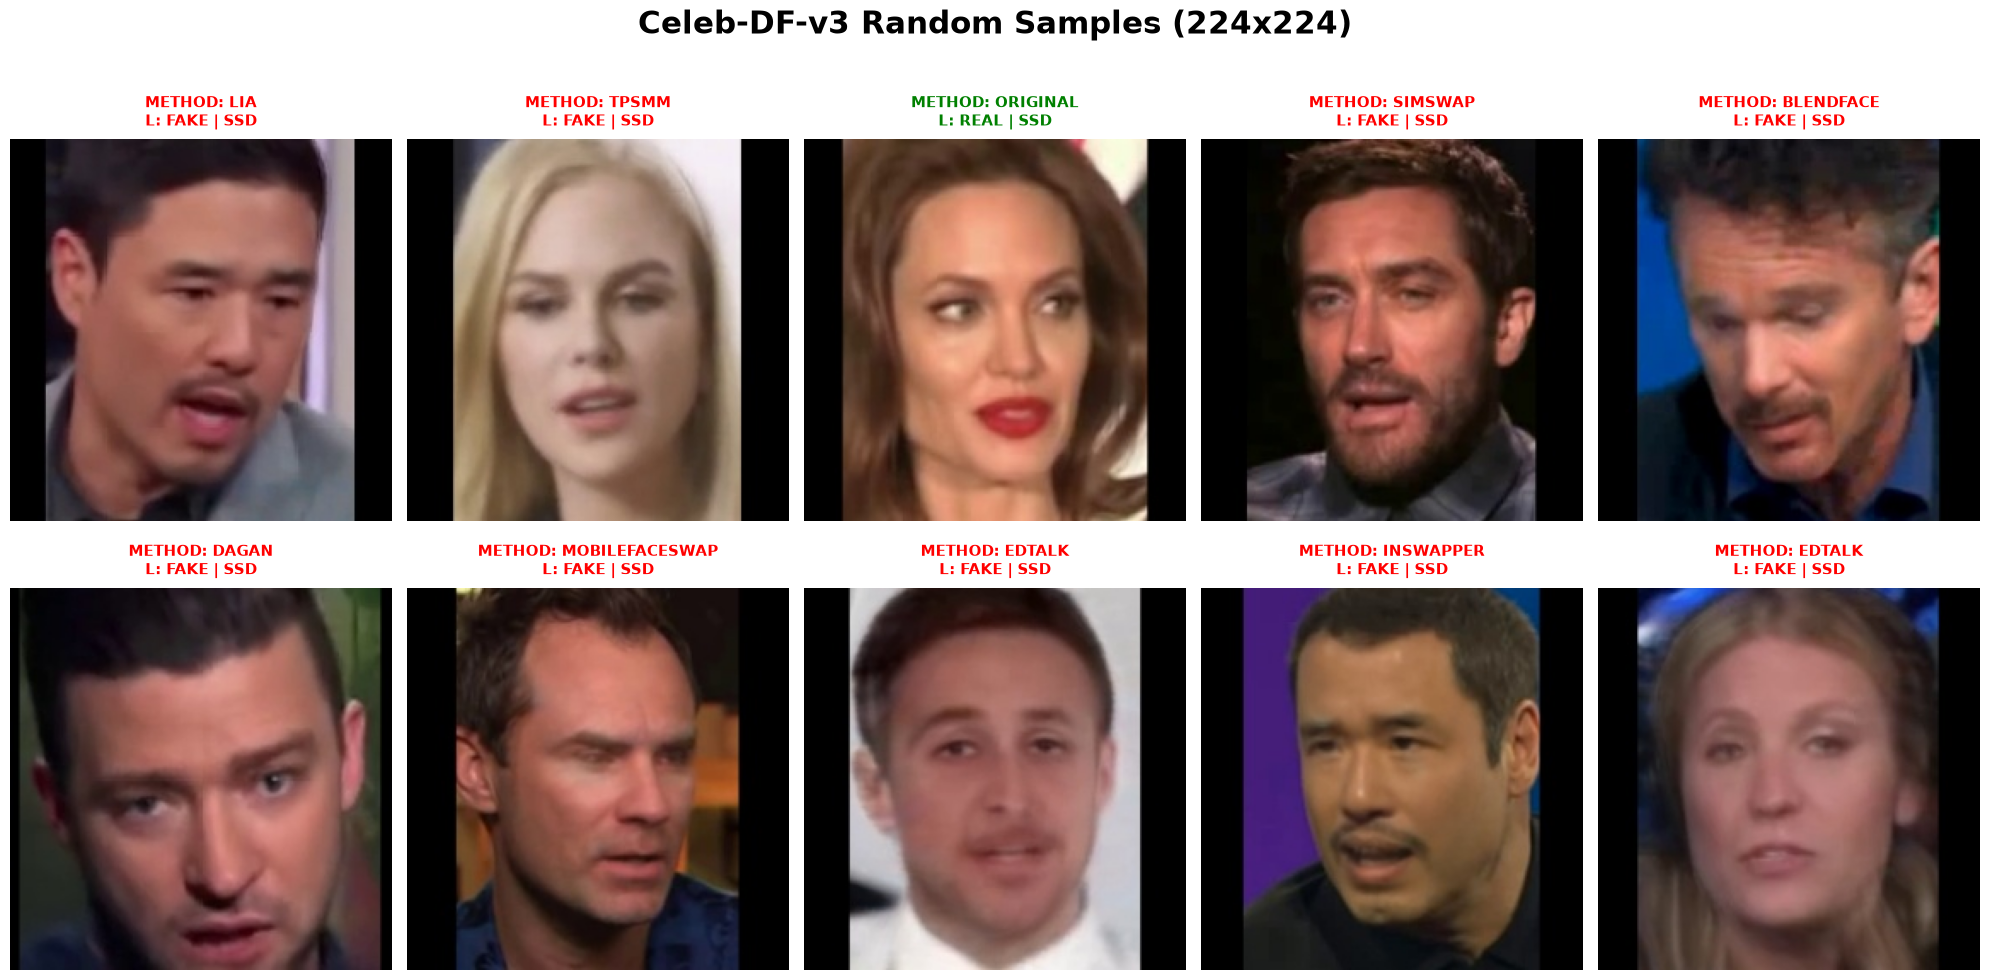

In [8]:
def show_celeb_frames_from_df(dataframe, num_images=10):
    print("\n--- VISUALIZING RANDOM FRAMES FROM CELEB-DF-V3 ---")
    
    sample = dataframe.sample(n=min(num_images, len(dataframe))).to_dict('records')
    
    if not sample:
        print("Zero images founded...")
        return 

    cols = 5
    rows = math.ceil(len(sample) / cols)
    
    plt.figure(figsize=(20, 5 * rows))
    plt.suptitle("Celeb-DF-v3 Random Samples (224x224)", fontsize=22, fontweight='bold', y=1.02)

    for i, row in enumerate(sample):
        plt.subplot(rows, cols, i+1)

        img_path = row['path']
        try:
            img = Image.open(img_path)
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, 'Loading Error', ha='center', va='center')
            
        plt.axis('off')

        label_text = "REAL" if row['label'] == 0 else "FAKE"
        method_name = str(row['method']).upper()
        
        strategy = "SSD" if "_ssd" in img_path else "CC"
        
        title_color = 'green' if label_text == "REAL" else 'red'
        plt.title(f"METHOD: {method_name}\nL: {label_text} | {strategy}", 
                  color=title_color, fontsize=11, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.show()

show_celeb_frames_from_df(celeb_frames, num_images=10)

## 8 - Saving Processed Data

To conclude this notebook, we save the fully cleaned and processed DataFrame to a local CSV file (`./processed_images/celeb_frames.csv`). This ensures our prepared dataset is safely stored and ready to be directly loaded into the next notebook of our pipeline without needing to re-run the preprocessing steps.

In [9]:
print("--- SAVING DATAFRAME ---")

output_dir = "./processed_images"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "celeb_frames.csv")
celeb_frames.to_csv(save_path, index=False)

print(f"Data succesfully saved to: {save_path}")

--- SAVING DATAFRAME ---
Data succesfully saved to: ./processed_images/celeb_frames.csv
